In [1]:
import sys
sys.path.append('../src')

from data import *
from plot import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Data loaded successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/09 13:41:24 WARN Utils: Your hostname, Siddharths-MacBook-Air-3.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.137 instead (on interface en0)
26/01/09 13:41:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/09 13:41:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loading raw data...


Dataset size: {'states': 3, 'stores': 10, 'categories': 3, 'departments': 7, 'items': 3049}
Sampling with seed 1...


26/01/09 13:41:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Sampled 50 items and 5 stores
Converting full dataset to long format...
Converting small sample to long format...
Joining full dataset with calendar and prices...
Joining small sample with calendar and prices...


...

Converting 10% sample to pandas...


26/01/09 13:47:31 WARN DAGScheduler: Broadcasting large task binary with size 1016.1 KiB


Filtering leading/trailing zeros on 10% sample...


26/01/09 13:53:44 WARN DAGScheduler: Broadcasting large task binary with size 1024.2 KiB


Original rows (10% sample): 4544614
Clean rows: 4521312
Computing demand statistics on 10% sample...

Demand classification on 10% sample:
category
Lumpy      2645
Erratic     283
Smooth       42
Name: count, dtype: int64

Computing zero sequence statistics on 10% sample...
Data loading complete!

Visualization dataframes (small sample): items_stores_sample, items_states_sample, items_total, dept_stores_sample, cat_stores_sample
Analysis dataframes (10% sample): revenue_10pct_pd, revenue_clean_pd
Statistics (10% sample): demand_stats, zero_stats, first_dates, last_dates
Data loaded successfully!


In [3]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print(f"\nVisualization sample: {len(item_ids_sample)} items × {len(store_ids_sample)} stores")
print(f"Analysis sample: 10% of items (~{len(demand_stats['item_id'].unique())} items)")
print(f"Total item-store combinations (10% sample): {len(demand_stats)}")
print(f"Date range: {items_stores_sample['date'].min()} to {items_stores_sample['date'].max()}")
print(f"Total observations (10% sample): {len(revenue_10pct_pd)}")
print(f"Clean observations (10% sample): {len(revenue_clean_pd)}")

DATASET OVERVIEW

Visualization sample: 50 items × 5 stores
Analysis sample: 10% of items (~297 items)
Total item-store combinations (10% sample): 2970
Date range: 2011-01-29 to 2016-05-22
Total observations (10% sample): 4544614
Clean observations (10% sample): 4521312



6. LEADING AND TRAILING ZEROS ANALYSIS

First sale dates (latest 10):
    first_sale_date  count
853      2015-05-30      4
854      2015-05-31      1
855      2015-06-01      1
856      2015-06-02      1
857      2015-06-03      2
858      2015-06-07      1
859      2015-06-18      1
860      2015-10-19      1
861      2015-11-10      1
862      2015-11-14      1

Last sale dates (earliest 10):
  last_sale_date  count
0     2014-06-09      1
1     2015-05-08      1
2     2015-09-08      1
3     2015-10-16      1
4     2015-10-20      1
5     2015-12-10      1
6     2015-12-19      1
7     2016-01-03      1
8     2016-01-13      1
9     2016-01-31      1


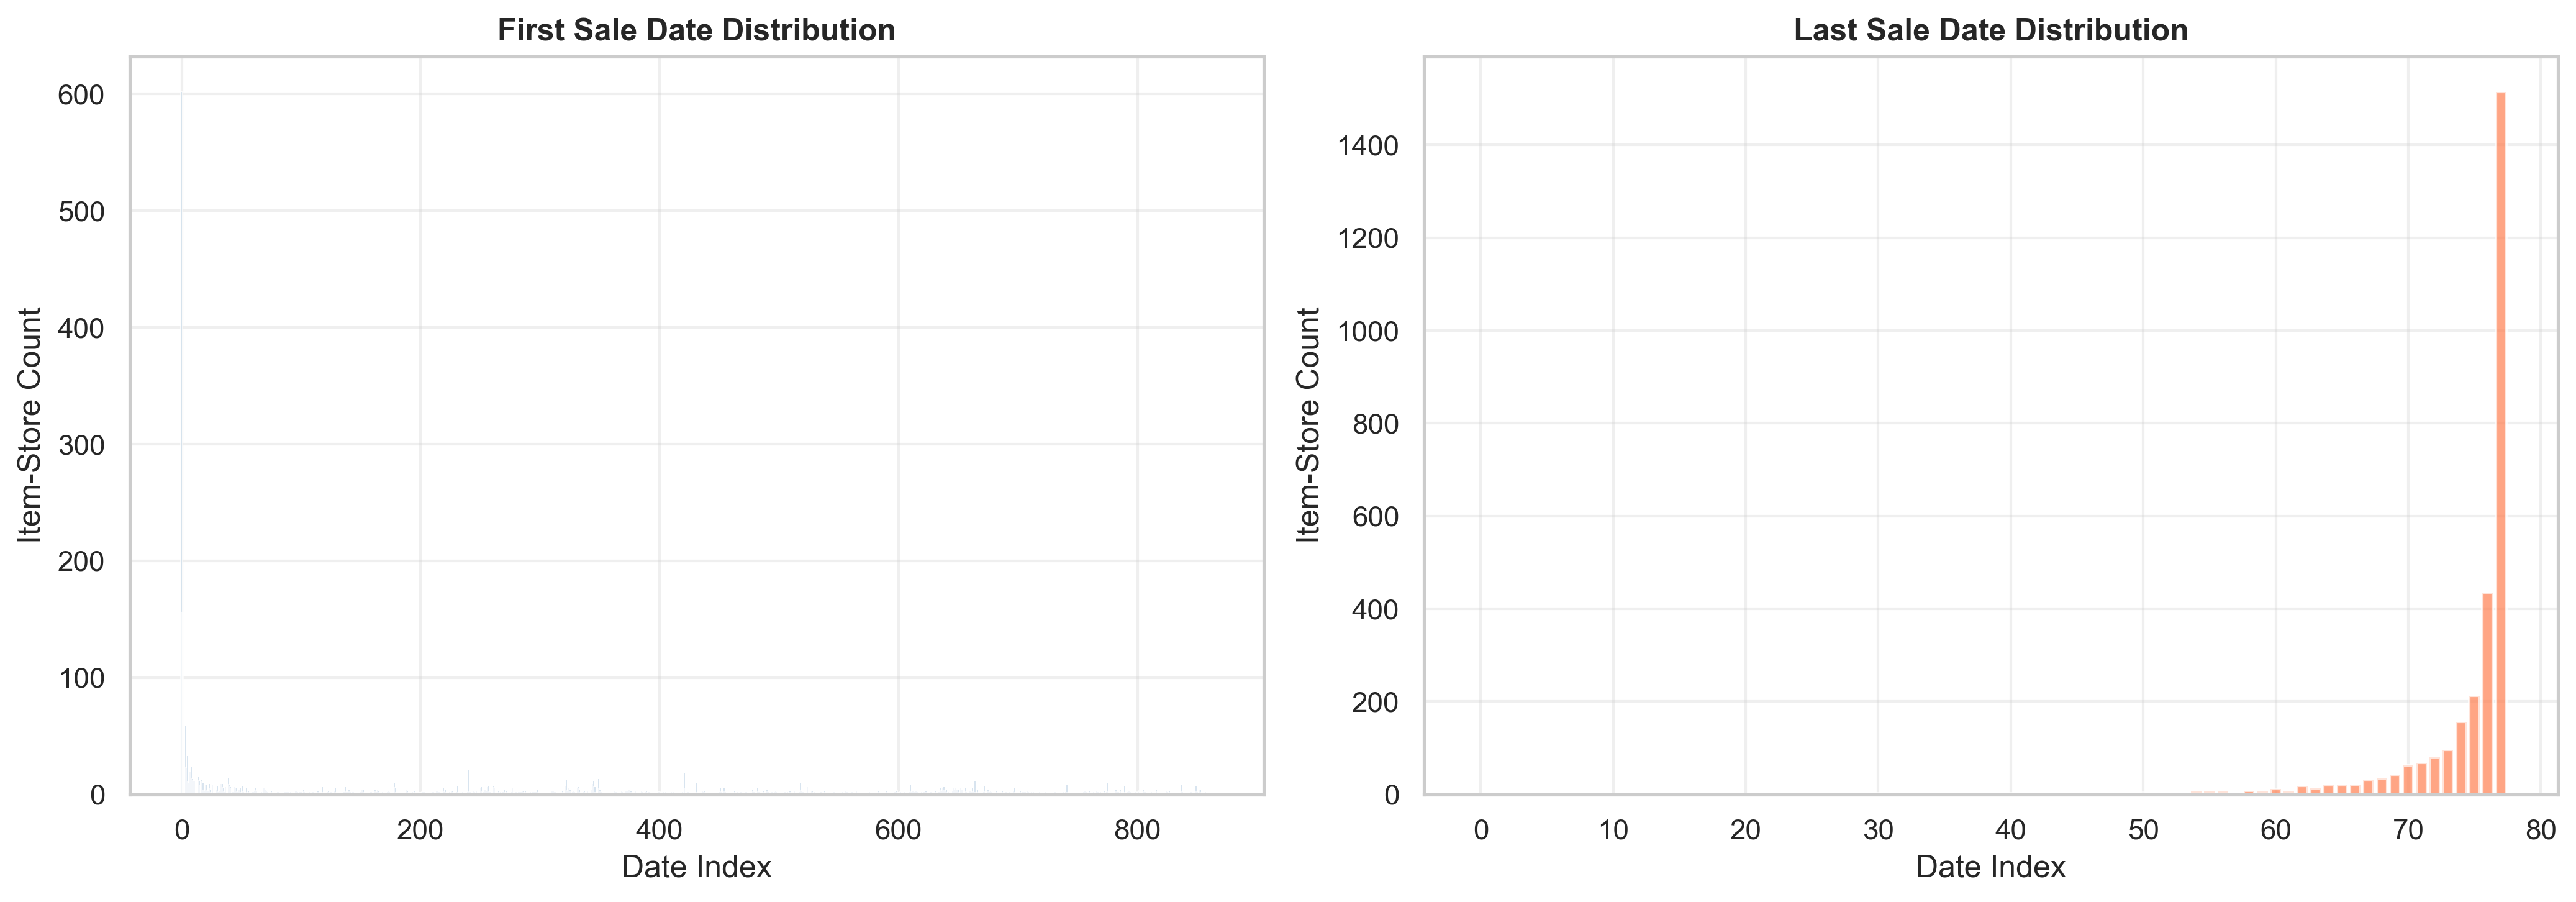


Original rows (10% sample): 4544614
Clean rows (after removing leading/trailing zeros): 4521312
Rows removed: 23302 (0.5%)


In [ ]:
print("\n" + "="*70)
print("6. LEADING AND TRAILING ZEROS ANALYSIS")
print("="*70)

print("\nFirst sale dates (latest 10):")
print(first_dates.tail(10))

print("\nLast sale dates (earliest 10):")
print(last_dates.head(10))

# Visualize date range distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(first_dates)), first_dates['count'], color='steelblue', alpha=0.7)
axes[0].set_title('First Sale Date Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date Index')
axes[0].set_ylabel('Item-Store Count')
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(last_dates)), last_dates['count'], color='coral', alpha=0.7)
axes[1].set_title('Last Sale Date Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date Index')
axes[1].set_ylabel('Item-Store Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('./paper/figures/date_ranges.pdf', bbox_inches='tight')
plt.show()

print(f"\nOriginal rows (10% sample): {len(revenue_10pct_pd)}")
print(f"Clean rows (after removing leading/trailing zeros): {len(revenue_clean_pd)}")
removed = len(revenue_10pct_pd) - len(revenue_clean_pd)
pct_removed = 100 * (1 - len(revenue_clean_pd)/len(revenue_10pct_pd))
print(f"Rows removed: {removed} ({pct_removed:.1f}%)")


7. DEMAND STATISTICS (ADI AND CV²)

Demand statistics summary:
               adi          cv2  mean_demand   std_demand
count  2970.000000  2970.000000  2970.000000  2970.000000
mean      4.166504     4.468900     1.352965     1.626587
std       4.149032     4.912869     2.230516     1.993860
min       1.017296     0.209069     0.018083     0.146239
25%       1.724047     1.538718     0.279757     0.629205
50%       2.762091     2.843689     0.610674     1.002545
75%       4.876041     5.457408     1.407484     1.771358
max      61.444444    65.399421    31.471410    28.950582

Demand pattern classification:
category
Lumpy      2645
Erratic     283
Smooth       42
Name: count, dtype: int64

Percentages:
category
Lumpy      89.1
Erratic     9.5
Smooth      1.4
Name: proportion, dtype: float64


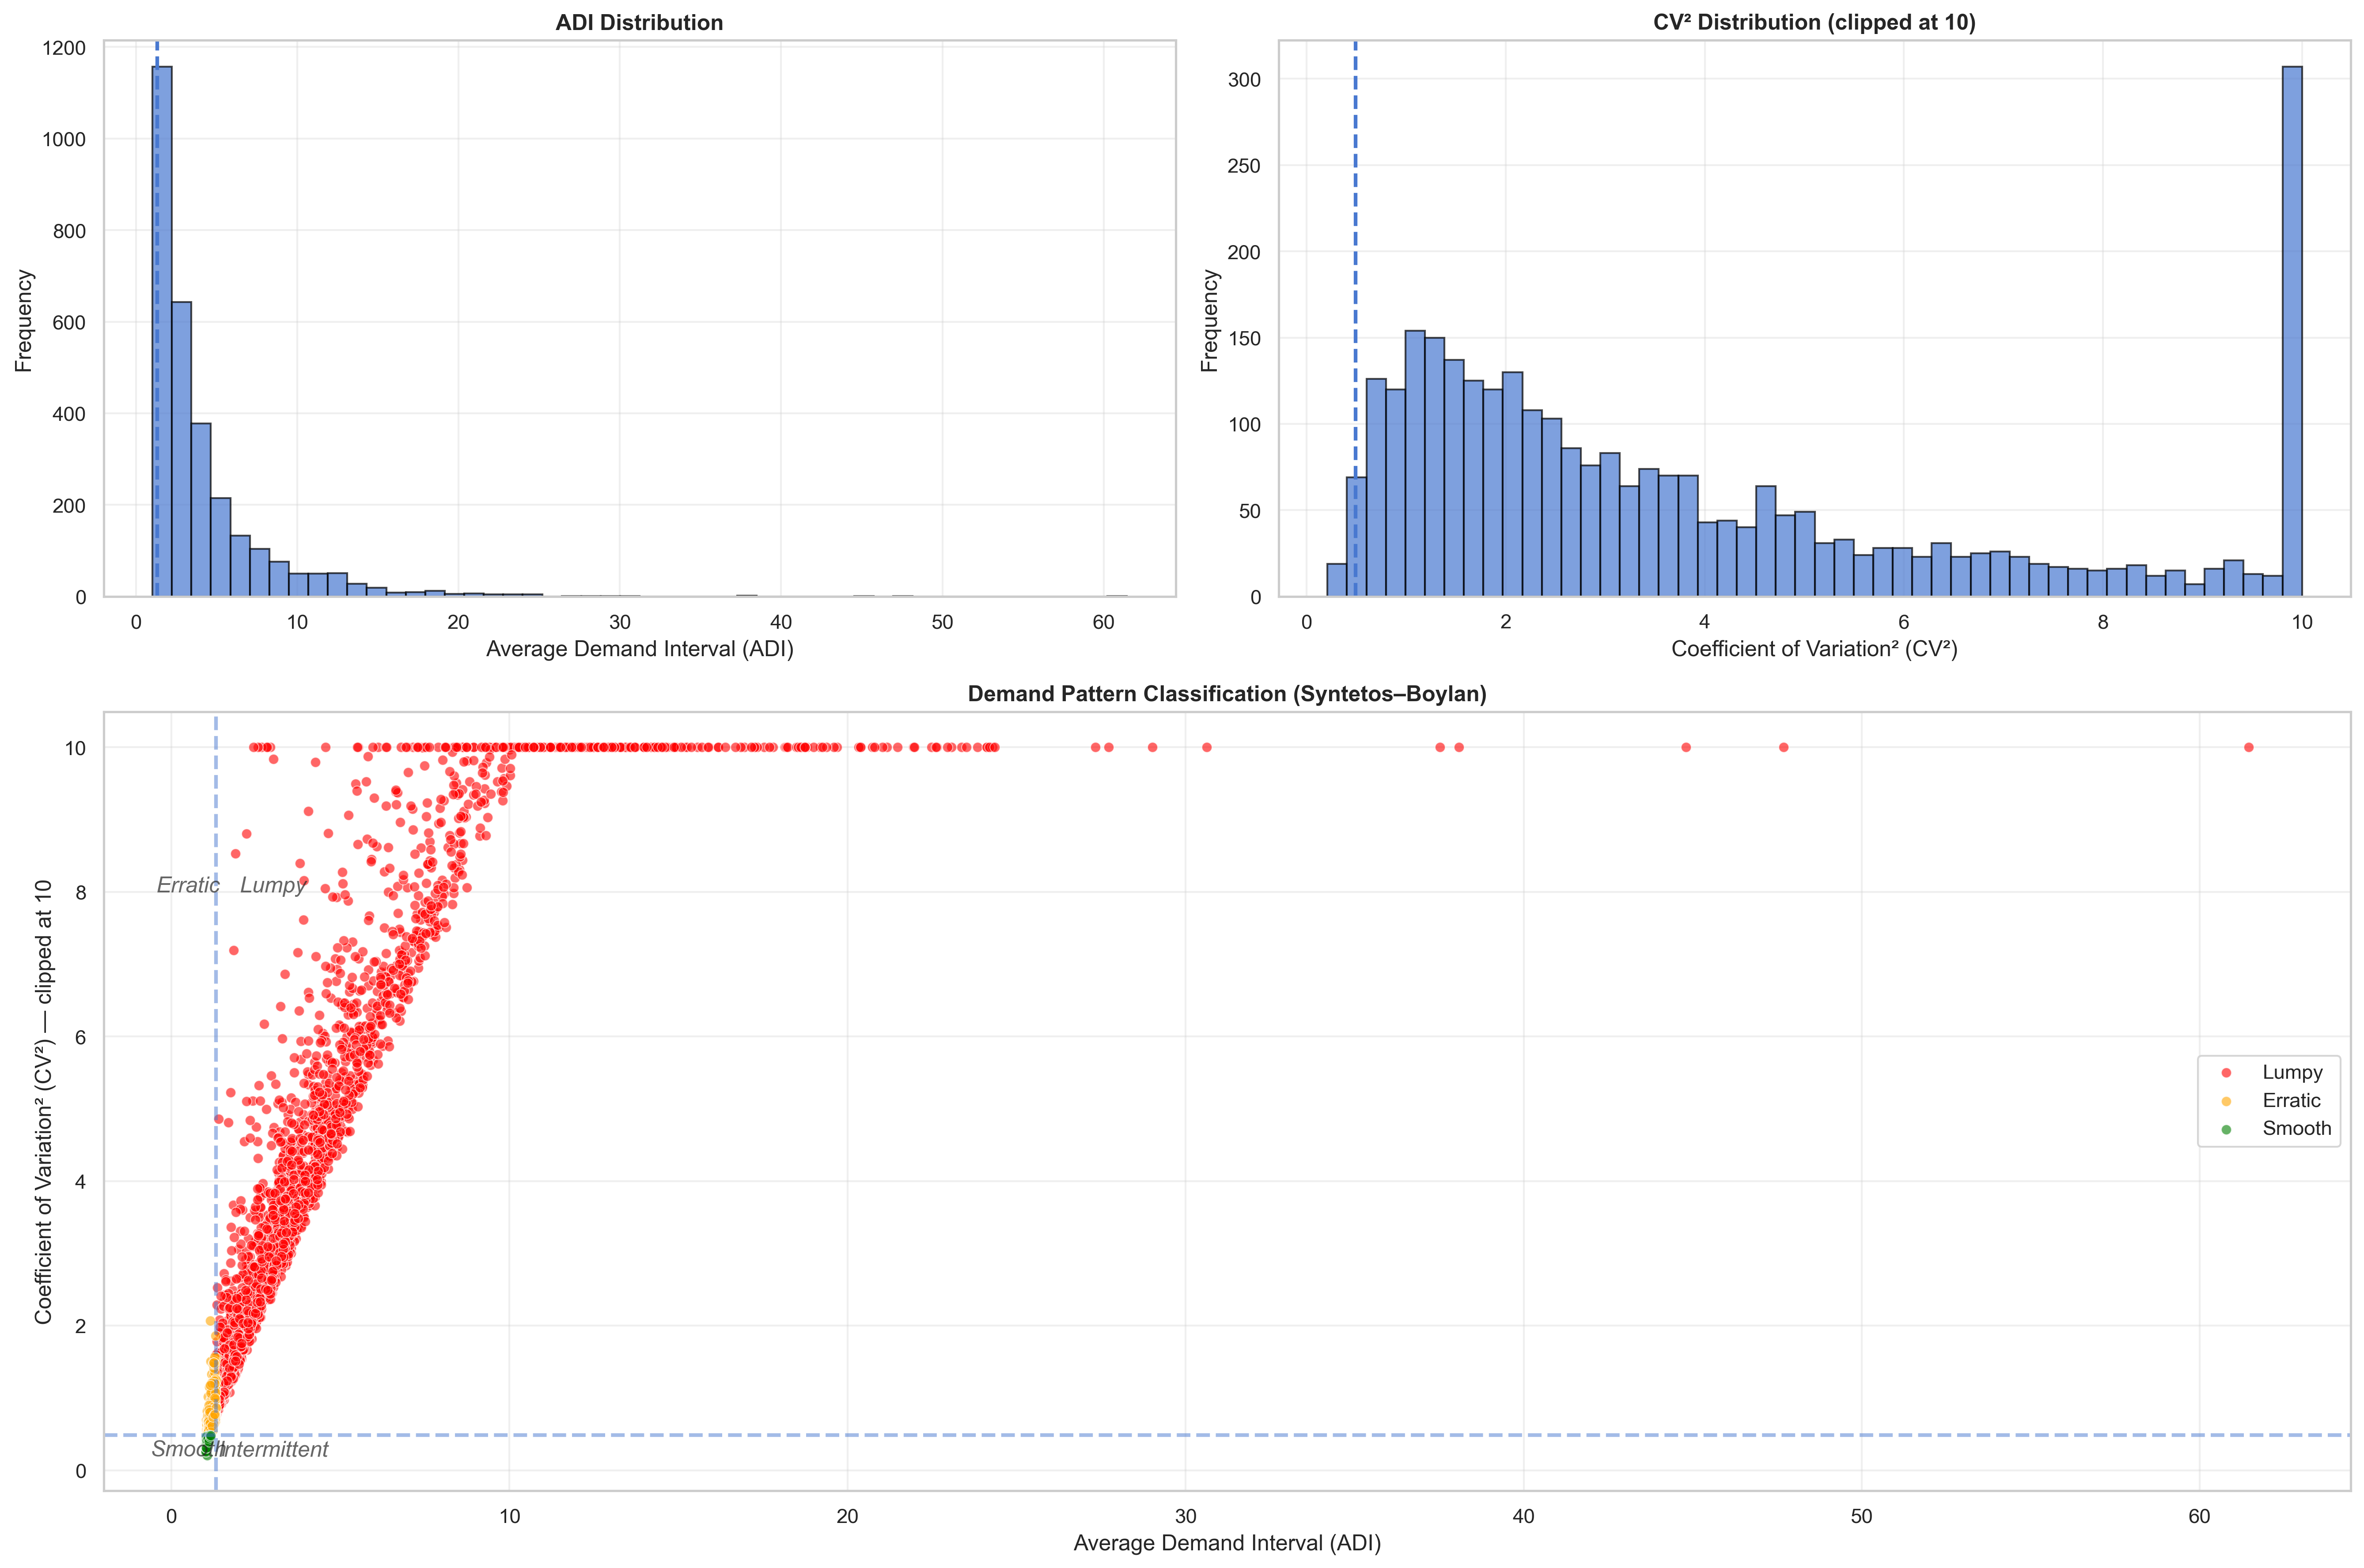

In [56]:
print("\n" + "="*70)
print("7. DEMAND STATISTICS (ADI AND CV²)")
print("="*70)

print("\nDemand statistics summary:")
print(demand_stats[['adi', 'cv2', 'mean_demand', 'std_demand']].describe())

print("\nDemand pattern classification:")
print(demand_stats['category'].value_counts())
print(f"\nPercentages:")
print(demand_stats['category'].value_counts(normalize=True).mul(100).round(1))

# ---------- Two on top, one large below ----------
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.4])

# --- ADI histogram (top-left) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(
    demand_stats['adi'].dropna(),
    bins=50, edgecolor='black', alpha=0.7
)
ax1.axvline(1.32, linestyle='--', linewidth=2)
ax1.set_title('ADI Distribution', fontweight='bold')
ax1.set_xlabel('Average Demand Interval (ADI)')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# --- CV² histogram (top-right) ---
ax2 = fig.add_subplot(gs[0, 1])
cv2_clipped = demand_stats['cv2'].dropna().clip(upper=10)
ax2.hist(
    cv2_clipped,
    bins=50, edgecolor='black', alpha=0.7
)
ax2.axvline(0.49, linestyle='--', linewidth=2)
ax2.set_title('CV² Distribution (clipped at 10)', fontweight='bold')
ax2.set_xlabel('Coefficient of Variation² (CV²)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

# --- ADI vs CV² scatter (bottom, spanning both columns) ---
ax3 = fig.add_subplot(gs[1, :])

colors = {'Smooth': 'green', 'Intermittent': 'blue', 'Erratic': 'orange', 'Lumpy': 'red'}

for cat in demand_stats['category'].unique():
    subset = demand_stats[demand_stats['category'] == cat]
    ax3.scatter(
        subset['adi'],
        subset['cv2'].clip(upper=10),
        alpha=0.6, s=30,
        label=cat,
        color=colors.get(cat, 'gray'),
        edgecolors='w', linewidth=0.5
    )

ax3.axvline(1.32, linestyle='--', linewidth=2, alpha=0.5)
ax3.axhline(0.49, linestyle='--', linewidth=2, alpha=0.5)
ax3.set_title('Demand Pattern Classification (Syntetos–Boylan)', fontweight='bold')
ax3.set_xlabel('Average Demand Interval (ADI)')
ax3.set_ylabel('Coefficient of Variation² (CV²) — clipped at 10')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Quadrant labels
ax3.text(0.5, 8, 'Erratic', ha='center', style='italic', alpha=0.7)
ax3.text(3, 8, 'Lumpy', ha='center', style='italic', alpha=0.7)
ax3.text(0.5, 0.2, 'Smooth', ha='center', style='italic', alpha=0.7)
ax3.text(3, 0.2, 'Intermittent', ha='center', style='italic', alpha=0.7)

plt.tight_layout()
plt.savefig('../paper/figures/demand_statistics_panel.pdf', bbox_inches='tight')
plt.show()


8. ZERO SEQUENCE ANALYSIS

Zero sequence statistics:
       avg_zero_seq  max_zero_seq  num_zero_seqs   zero_ratio
count   2970.000000   2970.000000    2970.000000  2970.000000
mean       5.331760    120.351852     213.955219     0.594626
std        5.231579    137.983802     112.515850     0.241718
min        1.052632      2.000000       8.000000     0.017002
25%        2.480382     32.000000     120.000000     0.419970
50%        3.779396     81.000000     203.000000     0.637955
75%        6.162184    146.000000     301.000000     0.794916
max       83.000000   1457.000000     493.000000     0.983725


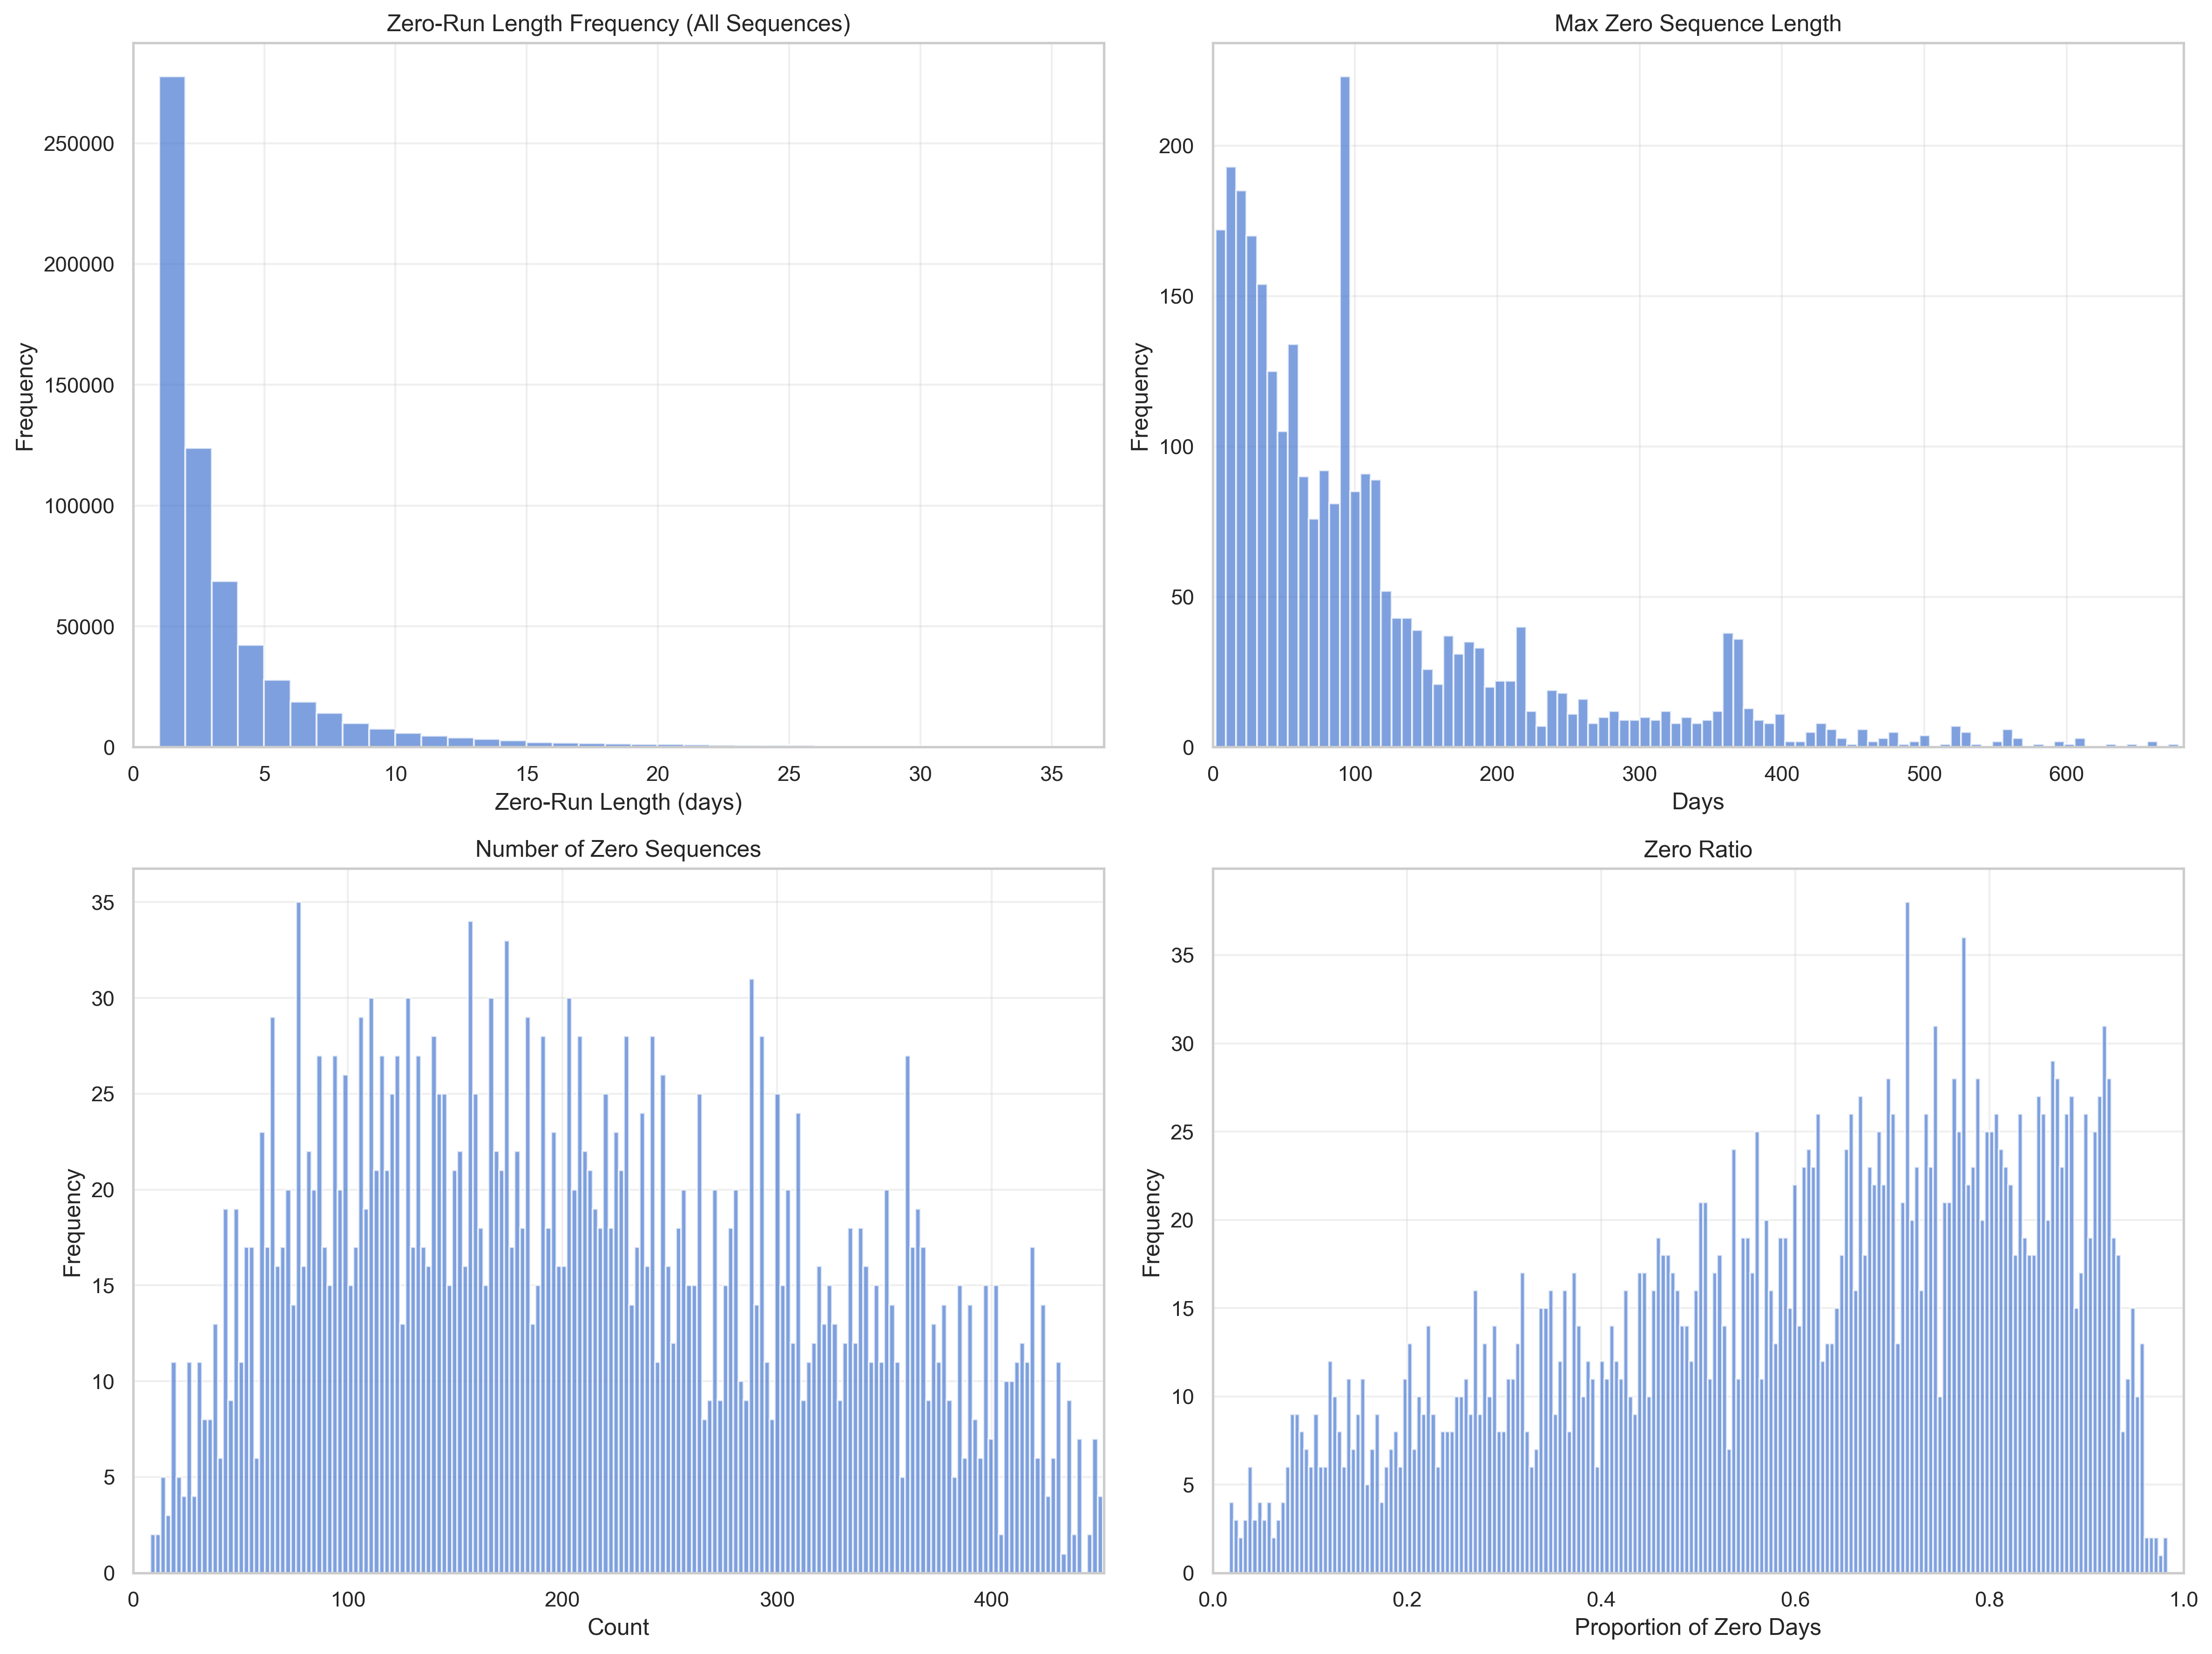

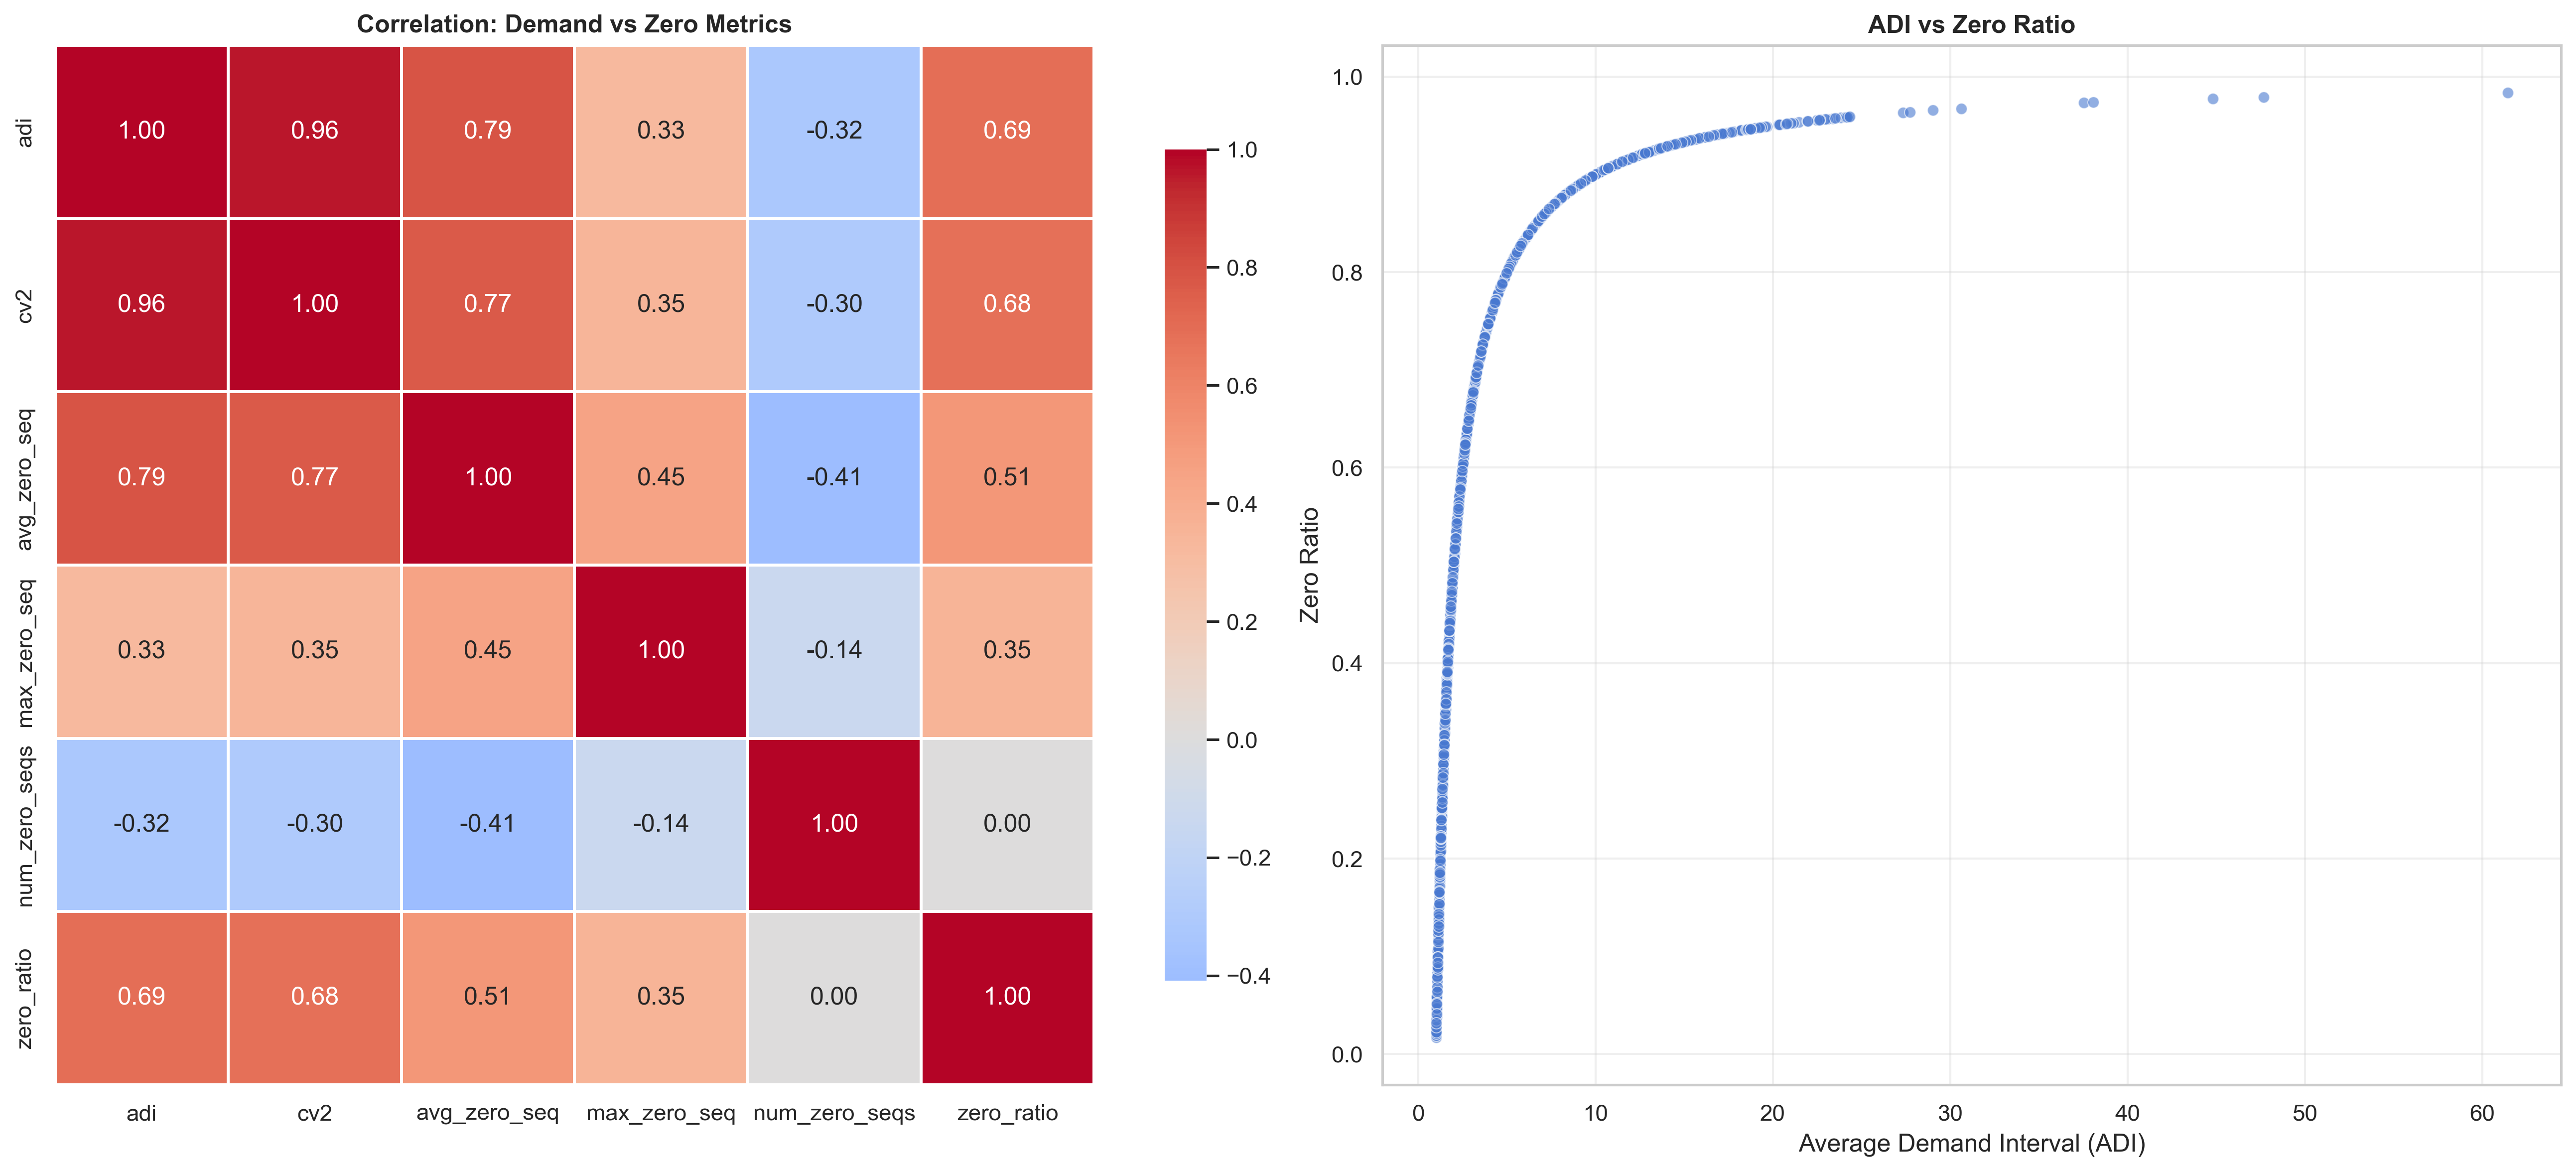

In [55]:
print("\n" + "="*70)
print("8. ZERO SEQUENCE ANALYSIS")
print("="*70)

all_zero_runs = (
    zero_stats['zero_seq_dist']
    .dropna()
    .explode()
    .astype(int)
)

if len(zero_stats) > 0:

    print("\nZero sequence statistics:")
    print(zero_stats[['avg_zero_seq', 'max_zero_seq',
                      'num_zero_seqs', 'zero_ratio']].describe())

    # ---------- sensible x-axis ranges (robust to outliers) ----------
    zr_max = all_zero_runs.quantile(0.99)
    max_seq_max = zero_stats['max_zero_seq'].quantile(0.99)
    num_seq_max = zero_stats['num_zero_seqs'].quantile(0.99)

    # ---------- Panel: 2x2 histograms ----------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # (1) TOTAL zero-run frequency distribution
    axes[0, 0].hist(
        all_zero_runs,
        bins=max(all_zero_runs), alpha=0.7
    )
    axes[0, 0].set_xlim(0, zr_max)
    axes[0, 0].set_title('Zero-Run Length Frequency (All Sequences)')
    axes[0, 0].set_xlabel('Zero-Run Length (days)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)

    # (2) Max zero sequence length
    axes[0, 1].hist(
        zero_stats['max_zero_seq'].dropna(),
        bins=200, alpha=0.7
    )
    axes[0, 1].set_xlim(0, max_seq_max)
    axes[0, 1].set_title('Max Zero Sequence Length')
    axes[0, 1].set_xlabel('Days')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)

    # (3) Number of zero sequences
    axes[1, 0].hist(
        zero_stats['num_zero_seqs'].dropna(),
        bins=200, alpha=0.7
    )
    axes[1, 0].set_xlim(0, num_seq_max)
    axes[1, 0].set_title('Number of Zero Sequences')
    axes[1, 0].set_xlabel('Count')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)

    # (4) Zero ratio
    axes[1, 1].hist(
        zero_stats['zero_ratio'].dropna(),
        bins=200, alpha=0.7
    )
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_title('Zero Ratio')
    axes[1, 1].set_xlabel('Proportion of Zero Days')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../paper/figures/zero_sequence_hist_panel.pdf', bbox_inches='tight')
    plt.show()

    # ---------- Correlation + scatter panel ----------
    merged = demand_stats.merge(
        zero_stats, on=['item_id', 'store_id'], how='left'
    )

    corr_cols = ['adi', 'cv2', 'avg_zero_seq',
                 'max_zero_seq', 'num_zero_seqs', 'zero_ratio']
    corr_matrix = merged[corr_cols].corr()

    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f',
        cmap='coolwarm', center=0,
        square=True, linewidths=1,
        cbar_kws={"shrink": 0.8}, ax=ax1
    )
    ax1.set_title('Correlation: Demand vs Zero Metrics', fontweight='bold')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(
        merged['adi'], merged['zero_ratio'],
        alpha=0.6, s=30, edgecolors='w', linewidth=0.5
    )
    ax2.set_xlabel('Average Demand Interval (ADI)')
    ax2.set_ylabel('Zero Ratio')
    ax2.set_title('ADI vs Zero Ratio', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../paper/figures/zero_sequence_correlation_panel.pdf', bbox_inches='tight')
    plt.show()

else:
    print("No zero sequences found in the clean data.")

In [57]:
print("\n" + "="*70)
print("9. SUMMARY")
print("="*70)

print(f"\nDemand patterns (10% sample):")
for cat, count in demand_stats['category'].value_counts().items():
    pct = 100 * count / len(demand_stats)
    print(f"  {cat:15s}: {count:5d} ({pct:5.1f}%)")

print("\n" + "="*70)
# print("EDA COMPLETE!")
print("Figures saved to ./paper/figures/")
print("="*70)


9. SUMMARY

Demand patterns (10% sample):
  Lumpy          :  2645 ( 89.1%)
  Erratic        :   283 (  9.5%)
  Smooth         :    42 (  1.4%)

Figures saved to ./paper/figures/
